# Spotify Dataset — Q2: K-Means Clustering

**Research Question 2:** Do songs form meaningful style clusters when grouped by their audio-derived factor profiles?

**Input:** Factor scores from Q1 (`Spotify_Q1_factor_scores.csv`)

---

### Pipeline
```
Q1 factor scores (3 columns per song)
    ↓  Section 2: Elbow + Silhouette → choose K
    ↓  Section 3: Fit final K-Means
    ↓  Section 4: Profile clusters (mean audio features)
    ↓  Section 5: Visualize in factor space
    ↓  Section 6: Cluster × Album_type cross-tab
    ↓  Section 7: Save outputs for Q3
```

## 0. Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import MinMaxScaler

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

OUTPUT_DIR = 'q2_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

AUDIO_FEATURES = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo'
]
FACTOR_COLS = [
    'Factor1_Intensity_Electronic',
    'Factor2_Danceability_Positive',
    'Factor3_Loudness / Instrumental Contrast'
]

print('Libraries loaded!')

Libraries loaded!


## 1. Load Q1 Factor Scores

In [17]:
# Load the full dataset with Q1 factor scores appended
df = pd.read_csv(os.path.join('q1_outputs', 'Spotify_Q1_factor_scores.csv'))

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Drop rows where factor scores are NaN
df_q2 = df.dropna(subset=FACTOR_COLS).copy()

# Drop rows where Views = 0 (no YouTube presence)
df_q2 = df_q2[df_q2['Views'] > 0].copy()
print(f'Working dataset after cleaning: {len(df_q2):,} songs')

# Log-transform engagement variables
for col in ['Views', 'Likes', 'Comments']:
    df_q2[f'log_{col}'] = np.log1p(df_q2[col])

# Extract factor score matrix for clustering
X_factors = df_q2[FACTOR_COLS].values
print(f'Clustering input shape: {X_factors.shape}')

print('\nFactor score descriptive statistics:')
display(df_q2[FACTOR_COLS].describe().round(3))

Dataset loaded: 20,124 rows × 42 columns
Working dataset after cleaning: 20,124 songs
Clustering input shape: (20124, 3)

Factor score descriptive statistics:


,Factor1_Intensity_Electronic,Factor2_Danceability_Positive,Factor3_Loudness / Instrumental Contrast
count,20124.000,20124.000,20124.000
mean,-0.000,0.000,0.000
std,0.995,0.989,0.977
min,-4.045,-4.035,-9.659
25%,-0.694,-0.634,-0.315
50%,0.074,0.091,0.158
75%,0.770,0.723,0.550
max,3.624,2.460,5.475


## 2. Select Optimal K

In [18]:
k_values = range(2, 10)
within_sse = []   # inertia — Elbow Method
sil = []          # Silhouette Score

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_factors)
    within_sse.append(kmeans.inertia_)
    sil.append(silhouette_score(X=X_factors, labels=kmeans.fit_predict(X_factors)))

print(f'{"K":>3}  {"Inertia (SSE)":>15}  {"Silhouette Score":>18}')
print('-' * 42)
for k, sse, s in zip(k_values, within_sse, sil):
    print(f'{k:>3}  {sse:>15.1f}  {s:>18.4f}')

best_k = list(k_values)[np.argmax(sil)]
print(f'\nBest K by Silhouette Score: K = {best_k}')

  K    Inertia (SSE)    Silhouette Score
------------------------------------------
  2          45808.5              0.2614
  3          35387.6              0.2671
  4          26615.2              0.2874
  5          22792.9              0.2562
  6          20366.7              0.2618
  7          18443.9              0.2491
  8          17273.1              0.2382
  9          15589.3              0.2514

Best K by Silhouette Score: K = 4


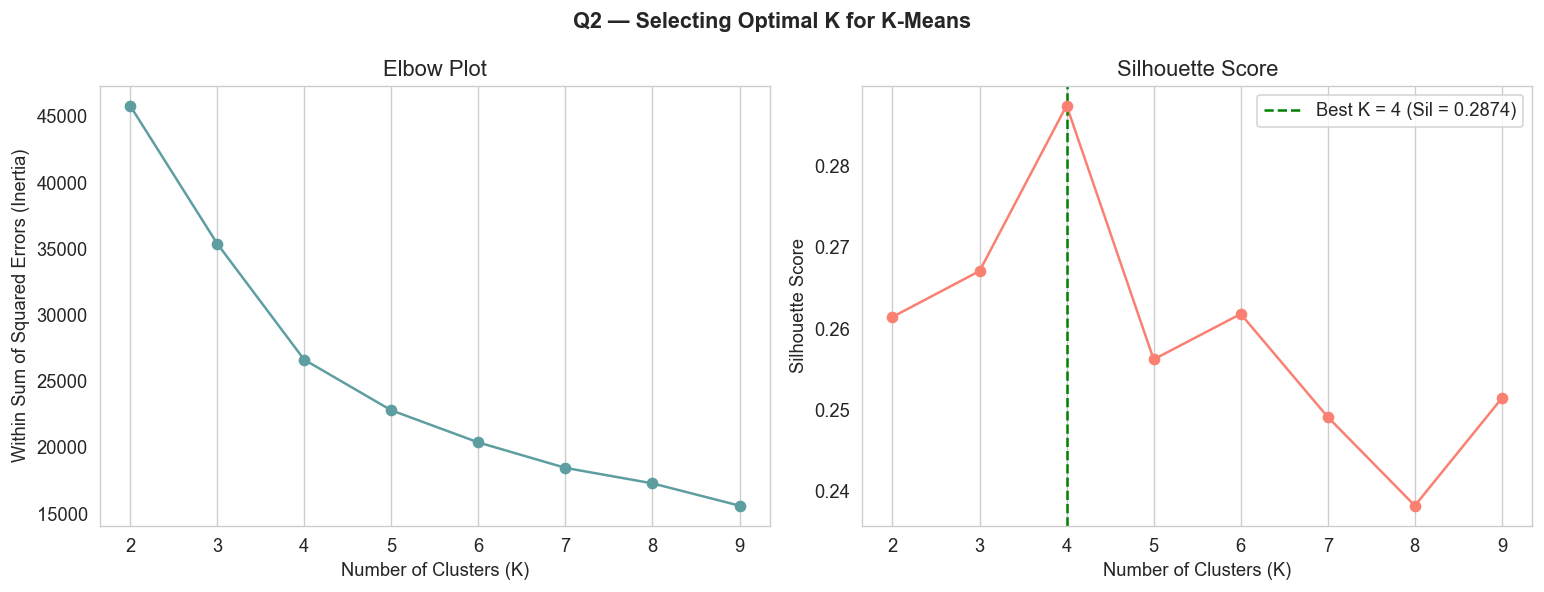

In [19]:
# Plot Elbow and Silhouette side by side — same style as lecture
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow plot
axes[0].scatter(k_values, within_sse, c='cadetblue', zorder=3)
axes[0].plot(k_values, within_sse, color='cadetblue')
axes[0].set_title('Elbow Plot')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within Sum of Squared Errors (Inertia)')
axes[0].set_xticks(list(k_values))
axes[0].grid(axis='y')

# Silhouette plot
axes[1].scatter(k_values, sil, c='salmon', zorder=3)
axes[1].plot(k_values, sil, color='salmon')
axes[1].axvline(x=best_k, color='green', linestyle='--',
                label=f'Best K = {best_k} (Sil = {max(sil):.4f})')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_values))
axes[1].legend()
axes[1].grid(axis='y')

plt.suptitle('Q2 — Selecting Optimal K for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Q2_k_selection.png'), dpi=300, bbox_inches='tight')
plt.show()

## 3. Fit Final K-Means Model

In [20]:
FINAL_K = 4

km_final = KMeans(n_clusters=FINAL_K, random_state=42)
df_q2['Cluster'] = km_final.fit_predict(X_factors)

sil_final = silhouette_score(X=X_factors, labels=df_q2['Cluster'])

print(f'Final K-Means Model (K = {FINAL_K})')
print(f'Silhouette Score : {sil_final:.4f}')
print(f'Inertia          : {km_final.inertia_:.2f}')
print(f'\nCluster sizes:')

cluster_counts = df_q2['Cluster'].value_counts().sort_index()
for c, n in cluster_counts.items():
    print(f'  Cluster {c}: {n:,} songs ({n/len(df_q2)*100:.1f}%)')

Final K-Means Model (K = 4)
Silhouette Score : 0.2874
Inertia          : 26615.24

Cluster sizes:
  Cluster 0: 6,218 songs (30.9%)
  Cluster 1: 8,309 songs (41.3%)
  Cluster 2: 4,910 songs (24.4%)
  Cluster 3: 687 songs (3.4%)


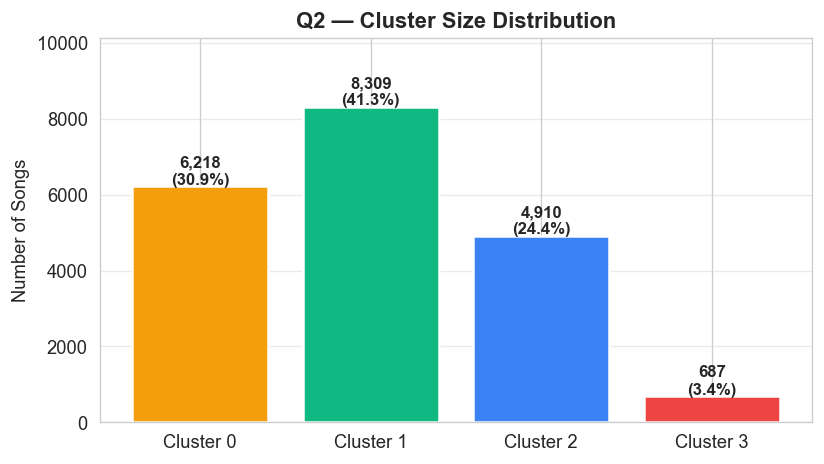

In [21]:
# Cluster size bar chart
cluster_pal = ['#F59E0B', '#10B981', '#3B82F6', '#EF4444']
sizes = df_q2['Cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f'Cluster {c}' for c in sizes.index], sizes.values,
              color=cluster_pal, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sizes.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df_q2)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Songs')
ax.set_title('Q2 — Cluster Size Distribution', fontweight='bold')
ax.set_ylim(0, max(sizes.values) * 1.22)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Q2_cluster_sizes.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4. Cluster Profiling — What Does Each Cluster Sound Like?

Using `.groupby().mean()` to compute the average audio features per cluster.

In [22]:
# Compute mean audio features per cluster — lecture method
cluster_profile = df_q2.groupby('Cluster')[AUDIO_FEATURES].mean()

print('Mean Audio Features per Cluster:')
display(cluster_profile.round(3))

print('\nMean Factor Scores per Cluster:')
display(df_q2.groupby('Cluster')[FACTOR_COLS].mean().round(3))

Mean Audio Features per Cluster:


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
Cluster,,,,,,,,,
0,0.546,0.820,-5.632,0.090,0.145,0.042,0.235,0.556,127.397
1,0.763,0.652,-7.046,0.121,0.233,0.024,0.174,0.622,117.597
2,0.514,0.439,-8.844,0.063,0.488,0.048,0.172,0.384,119.182
3,0.339,0.151,-25.329,0.083,0.842,0.637,0.154,0.210,103.595



Mean Factor Scores per Cluster:


,Factor1_Intensity_Electronic,Factor2_Danceability_Positive,Factor3_Loudness / Instrumental Contrast
Cluster,,,
0,0.938,-0.567,0.043
1,0.007,0.870,-0.031
2,-1.011,-0.604,0.486
3,-1.352,-1.078,-3.491


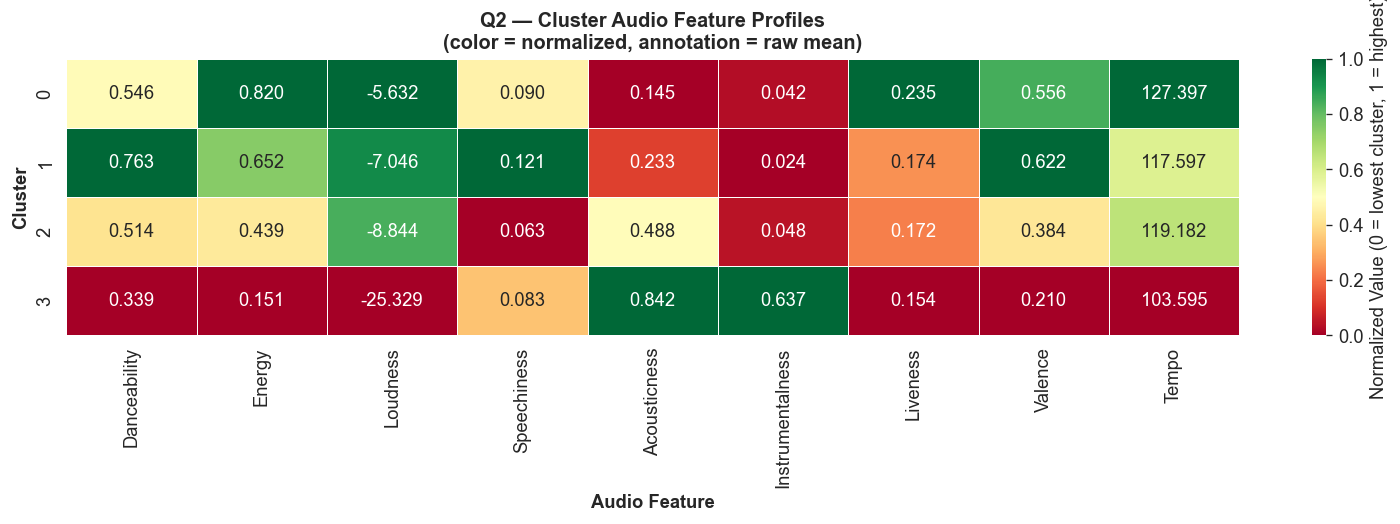

In [23]:
# Cluster profile heatmap

mms = MinMaxScaler()
profile_norm = pd.DataFrame(
    mms.fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(
    profile_norm,
    annot=cluster_profile.round(3),
    fmt='.3f',
    cmap='RdYlGn',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Normalized Value (0 = lowest cluster, 1 = highest)'}
)
ax.set_xlabel('Audio Feature', fontweight='bold')
ax.set_ylabel('Cluster', fontweight='bold')
ax.set_title(
    'Q2 — Cluster Audio Feature Profiles\n'
    '(color = normalized, annotation = raw mean)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Q2_cluster_profiles.png'), dpi=300, bbox_inches='tight')
plt.show()

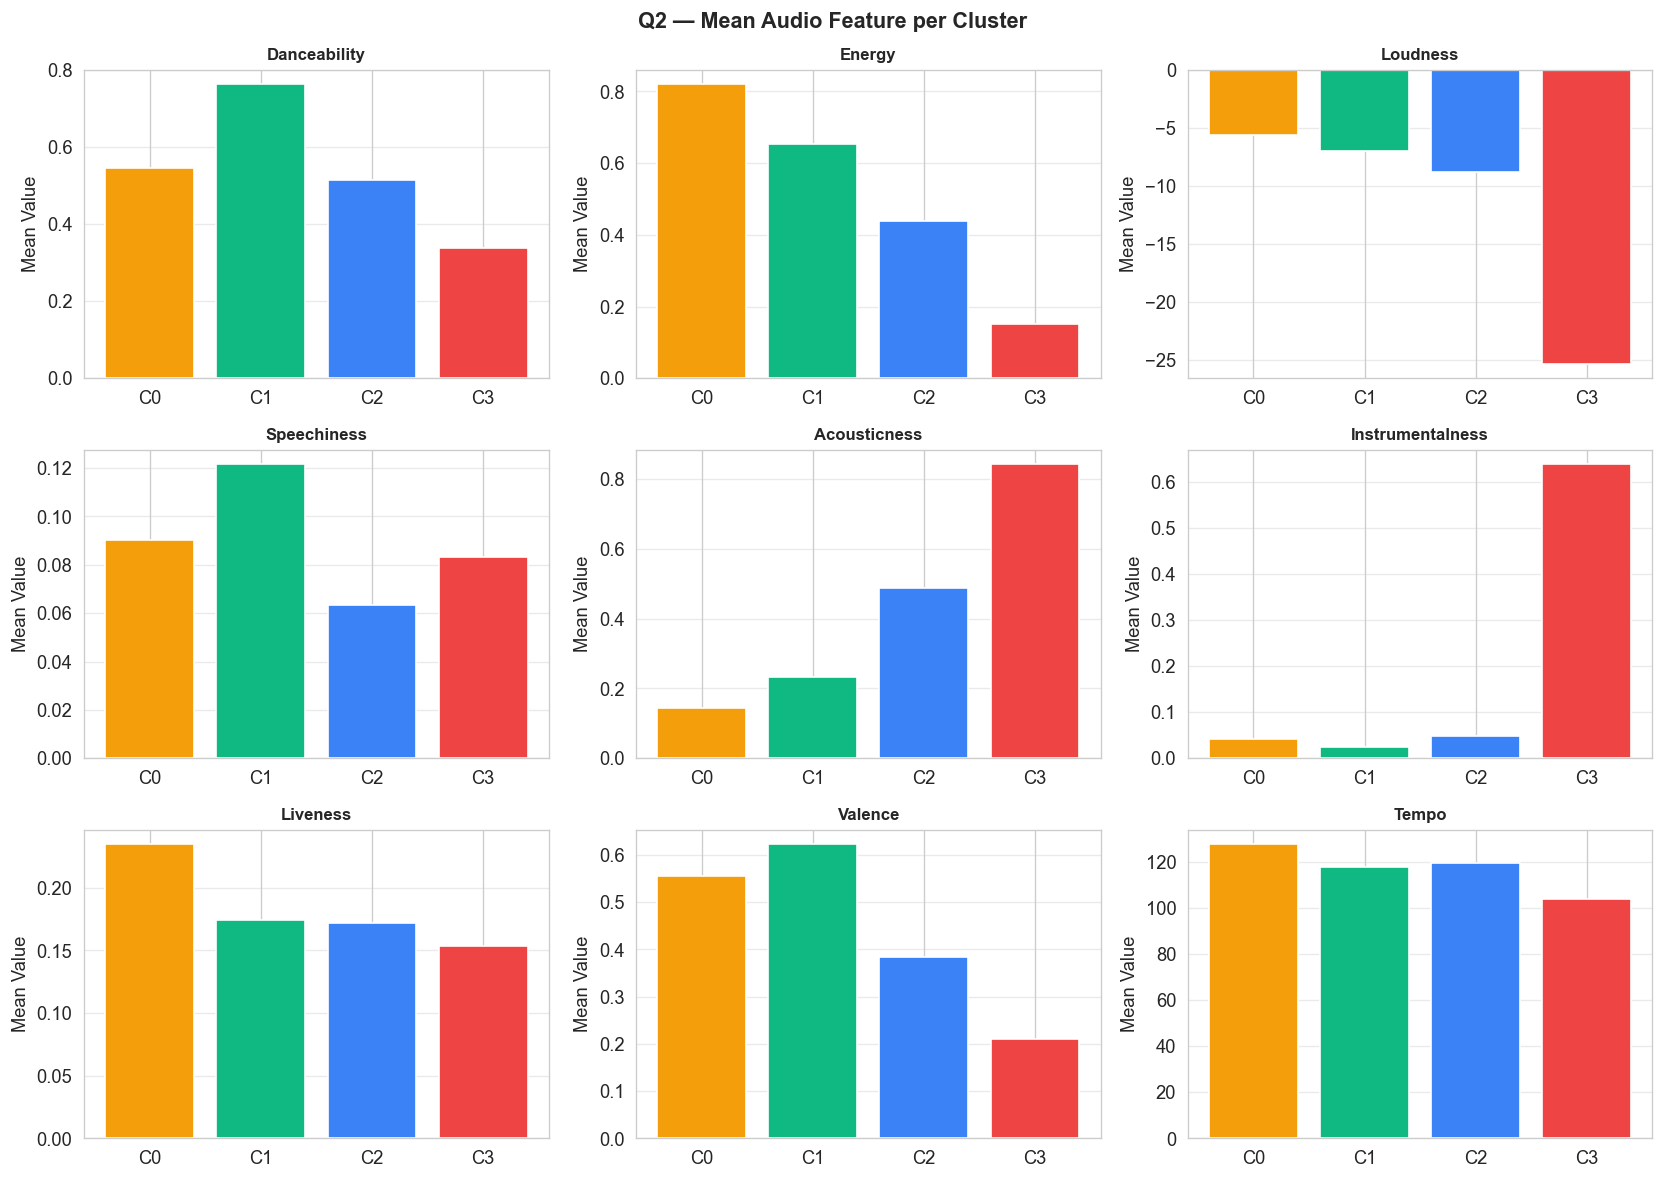

In [24]:
# Bar chart: mean audio features per cluster
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(AUDIO_FEATURES):
    vals = cluster_profile[feat].values
    axes[i].bar([f'C{c}' for c in range(FINAL_K)], vals,
                color=cluster_pal, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Mean Value')
    axes[i].grid(axis='y', alpha=0.4)

plt.suptitle('Q2 — Mean Audio Feature per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Q2_cluster_bar_profiles.png'), dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Assign interpretive names based on the profile table above
CLUSTER_NAMES = {
    0: 'High-Energy Electronic',
    1: 'Acoustic & Ballad',
    2: 'Mainstream Pop',
    3: 'Niche / Spoken / Live',
}

df_q2['Cluster_Name'] = df_q2['Cluster'].map(CLUSTER_NAMES)

print('Cluster Interpretation')
for k, v in CLUSTER_NAMES.items():
    n = (df_q2['Cluster'] == k).sum()
    print(f'  Cluster {k} → "{v}" | {n:,} songs ({n/len(df_q2)*100:.1f}%)')

print('\nNote: Verify cluster names against the profile heatmap and bar charts above.')

Cluster Interpretation
  Cluster 0 → "High-Energy Electronic" | 6,218 songs (30.9%)
  Cluster 1 → "Acoustic & Ballad" | 8,309 songs (41.3%)
  Cluster 2 → "Mainstream Pop" | 4,910 songs (24.4%)
  Cluster 3 → "Niche / Spoken / Live" | 687 songs (3.4%)

Note: Verify cluster names against the profile heatmap and bar charts above.


## 5. Visualize Clusters in Factor Space

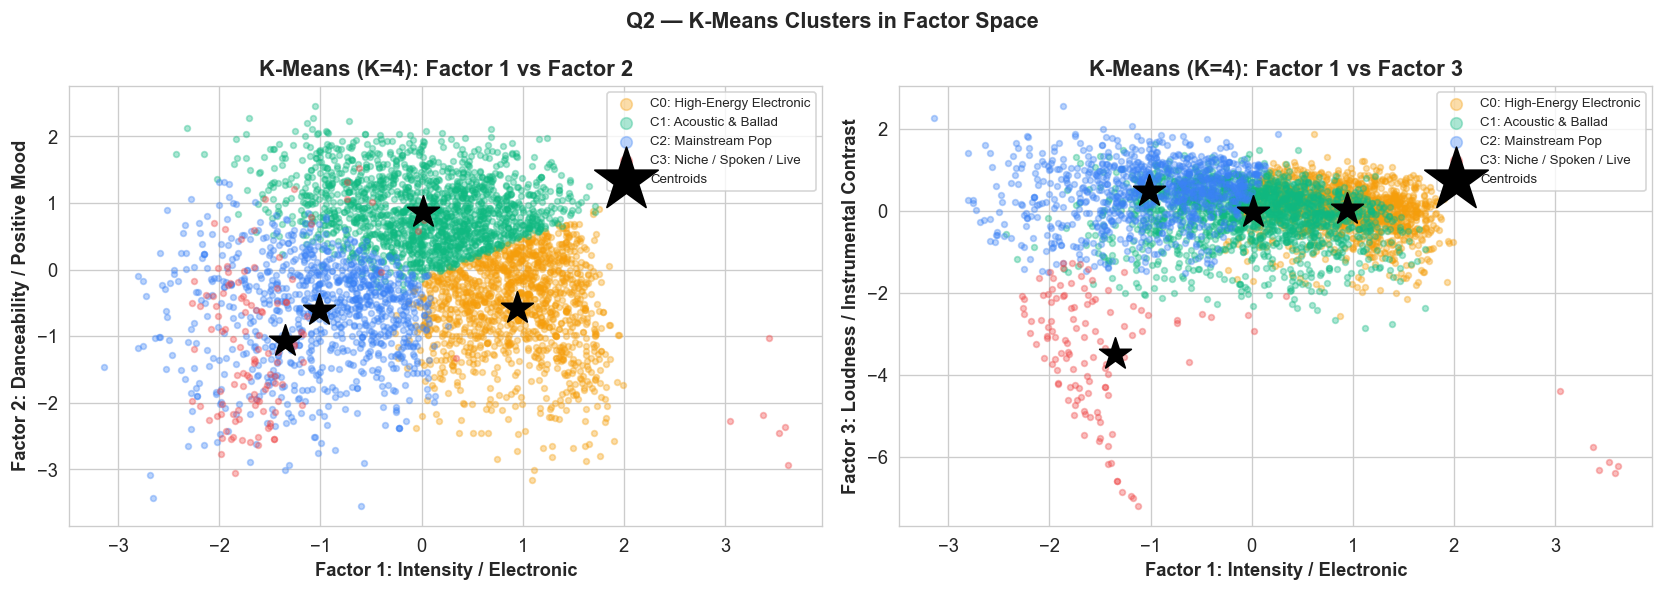

In [26]:
# Scatter plot of clusters in factor space
# Shows how well K-Means separated the groups visually
f1, f2, f3 = FACTOR_COLS
centroids = km_final.cluster_centers_

# Subsample for faster rendering
plot_df = df_q2.sample(n=min(4000, len(df_q2)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c, (name, color) in enumerate(zip(CLUSTER_NAMES.values(), cluster_pal)):
    mask = plot_df['Cluster'] == c
    axes[0].scatter(plot_df.loc[mask, f1], plot_df.loc[mask, f2],
                    color=color, label=f'C{c}: {name}', alpha=0.35, s=12)
    axes[1].scatter(plot_df.loc[mask, f1], plot_df.loc[mask, f3],
                    color=color, label=f'C{c}: {name}', alpha=0.35, s=12)

# Mark centroids
axes[0].scatter(centroids[:, 0], centroids[:, 1], marker='*', s=400, c='black',
                zorder=5, label='Centroids')
axes[1].scatter(centroids[:, 0], centroids[:, 2], marker='*', s=400, c='black',
                zorder=5, label='Centroids')

axes[0].set_xlabel('Factor 1: Intensity / Electronic', fontweight='bold')
axes[0].set_ylabel('Factor 2: Danceability / Positive Mood', fontweight='bold')
axes[0].set_title(f'K-Means (K={FINAL_K}): Factor 1 vs Factor 2', fontweight='bold')
axes[0].legend(fontsize=8, markerscale=2)

axes[1].set_xlabel('Factor 1: Intensity / Electronic', fontweight='bold')
axes[1].set_ylabel('Factor 3: Loudness / Instrumental Contrast', fontweight='bold')
axes[1].set_title(f'K-Means (K={FINAL_K}): Factor 1 vs Factor 3', fontweight='bold')
axes[1].legend(fontsize=8, markerscale=2)

plt.suptitle('Q2 — K-Means Clusters in Factor Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Q2_cluster_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Cluster × Album_type Cross-Tabulation

In [27]:
# Cross-tabulation: Album_type distribution within each cluster
print('Cluster × Album_type (Count):')
ct_count = pd.crosstab(df_q2['Cluster'], df_q2['Album_type'], margins=True)
display(ct_count)

print('\n Cluster × Album_type (Row %, within each cluster)')
ct_pct = pd.crosstab(df_q2['Cluster'], df_q2['Album_type'], normalize='index') * 100
display(ct_pct.round(1))

Cluster × Album_type (Count):


Album_type,album,compilation,single,All
Cluster,,,,
0,4625,250,1343,6218
1,5597,252,2460,8309
2,3720,219,971,4910
3,584,47,56,687
All,14526,768,4830,20124



 Cluster × Album_type (Row %, within each cluster)


Album_type,album,compilation,single
Cluster,,,
0,74.4,4.0,21.6
1,67.4,3.0,29.6
2,75.8,4.5,19.8
3,85.0,6.8,8.2


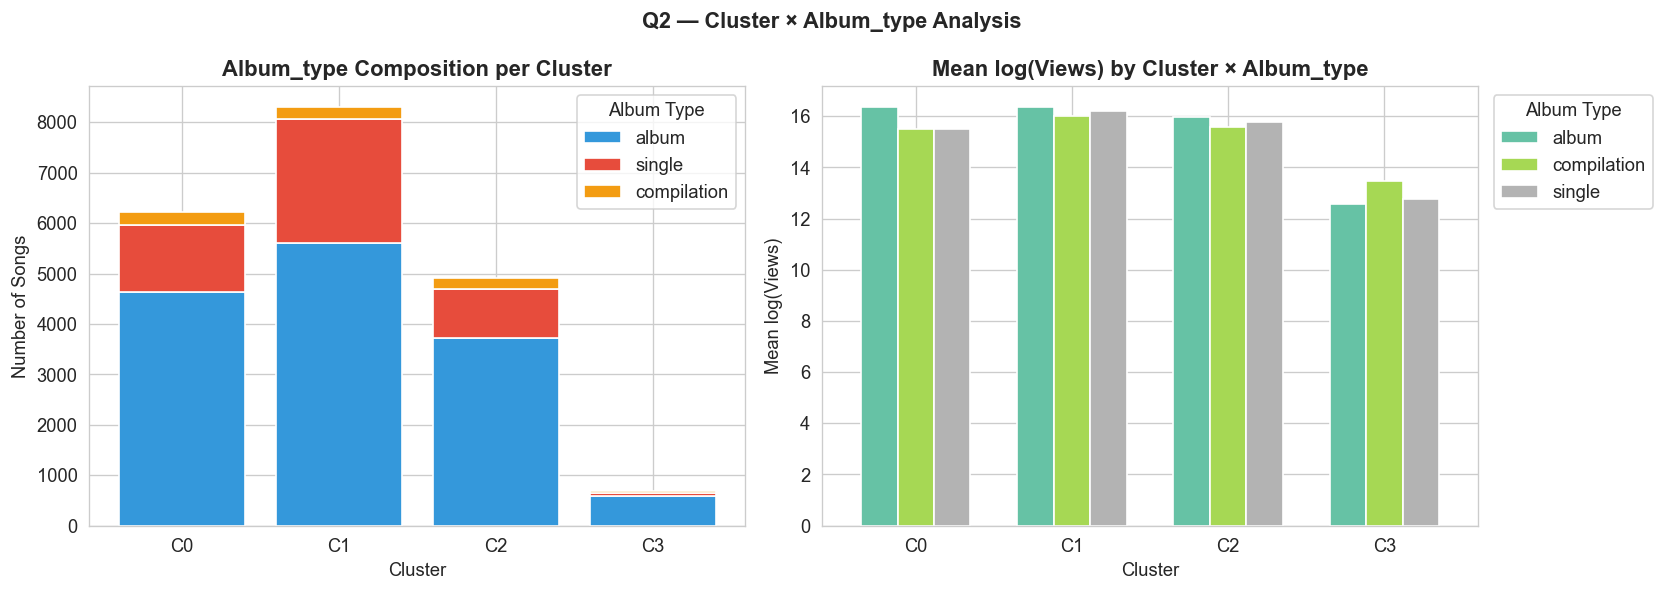


Mean log(Views) by Cluster × Album_type


Album_type,album,compilation,single
Cluster,,,
0,16.348,15.487,15.511
1,16.372,16.008,16.191
2,15.968,15.561,15.768
3,12.554,13.463,12.782


In [28]:
# Mean engagement by Cluster × Album_type
cross_views = df_q2.groupby(['Cluster', 'Album_type'])['log_Views'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: Album_type composition
album_colors = {'album': '#3498db', 'single': '#e74c3c', 'compilation': '#f39c12'}
bottom = np.zeros(FINAL_K)
ct_no_all = ct_count.drop('All', axis=0).drop('All', axis=1)
for atype, color in album_colors.items():
    if atype in ct_no_all.columns:
        vals = ct_no_all[atype].values
        axes[0].bar([f'C{c}' for c in range(FINAL_K)], vals,
                    bottom=bottom, color=color, label=atype,
                    edgecolor='white')
        bottom += vals
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Number of Songs')
axes[0].set_title('Album_type Composition per Cluster', fontweight='bold')
axes[0].legend(title='Album Type')

# Grouped bar: mean log(Views)
cross_views.plot(kind='bar', ax=axes[1], colormap='Set2',
                 edgecolor='white', width=0.7)
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Mean log(Views)')
axes[1].set_title('Mean log(Views) by Cluster × Album_type', fontweight='bold')
axes[1].legend(title='Album Type', bbox_to_anchor=(1.01, 1))
axes[1].set_xticklabels([f'C{c}' for c in cross_views.index], rotation=0)

plt.suptitle('Q2 — Cluster × Album_type Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Q2_cluster_albumtype.png'), dpi=300, bbox_inches='tight')
plt.show()

print('\nMean log(Views) by Cluster × Album_type')
display(cross_views.round(3))

## 7. Summary Table

In [29]:
summary = df_q2.groupby('Cluster').agg(
    Cluster_Name=('Cluster_Name', 'first'),
    N_Songs=('Cluster', 'count'),
    Danceability=('Danceability', 'mean'),
    Energy=('Energy', 'mean'),
    Loudness=('Loudness', 'mean'),
    Acousticness=('Acousticness', 'mean'),
    Speechiness=('Speechiness', 'mean'),
    Valence=('Valence', 'mean'),
    Mean_logViews=('log_Views', 'mean'),
    Mean_logLikes=('log_Likes', 'mean'),
    Mean_logComments=('log_Comments', 'mean'),
).round(3)

print('Q2 Cluster Summary:')
display(summary)

summary.to_csv(os.path.join(OUTPUT_DIR, 'Q2_cluster_summary.csv'))
print('Summary saved.')

Q2 Cluster Summary:


,Cluster_Name,N_Songs,Danceability,Energy,Loudness,Acousticness,Speechiness,Valence,Mean_logViews,Mean_logLikes,Mean_logComments
Cluster,,,,,,,,,,,
0,High-Energy Electronic,6218,0.546,0.820,-5.632,0.145,0.090,0.556,16.133,11.375,7.845
1,Acoustic & Ballad,8309,0.763,0.652,-7.046,0.233,0.121,0.622,16.308,11.630,7.903
2,Mainstream Pop,4910,0.514,0.439,-8.844,0.488,0.063,0.384,15.910,11.226,7.489
3,Niche / Spoken / Live,687,0.339,0.151,-25.329,0.842,0.083,0.210,12.634,8.214,4.457


Summary saved.


## 8. Save Outputs for Q3

In [30]:
# Save dataset for Q3 regression
q2_out = os.path.join(OUTPUT_DIR, 'Spotify_Q2_with_clusters.csv')
df_q2.to_csv(q2_out, index=False)

cluster_profile.to_csv(os.path.join(OUTPUT_DIR, 'Q2_cluster_audio_profiles.csv'))

name_df = pd.DataFrame(list(CLUSTER_NAMES.items()), columns=['Cluster', 'Cluster_Name'])
name_df.to_csv(os.path.join(OUTPUT_DIR, 'Q2_cluster_names.csv'), index=False)

print('Files saved.')

Files saved.
